Introduction & Problem Statement

The goal is to predict medical insurance claim amounts (charges) based on personal data such as age, BMI, smoking status, and other factors.
This helps insurance companies estimate expected costs for individuals.

Objective: Build a Linear Regression model to predict insurance charges and analyze how key factors like BMI, age, and smoking status impact them.

Shape of dataset: (1338, 7)

Columns:
 Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Summary statistics:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


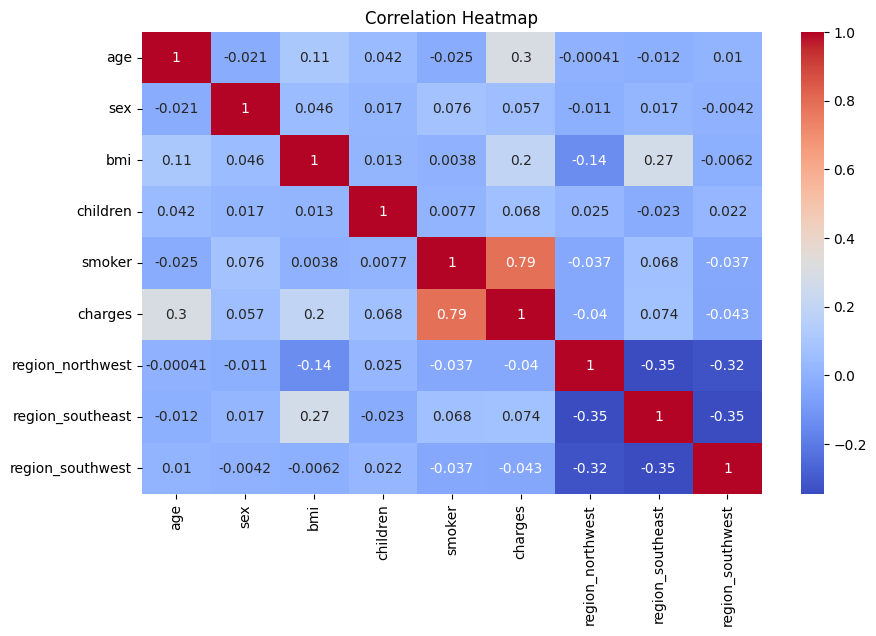

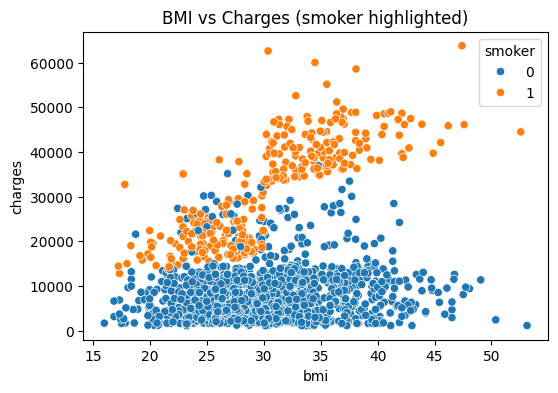

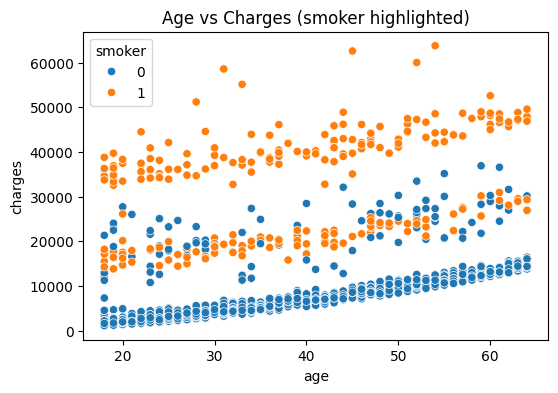

Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


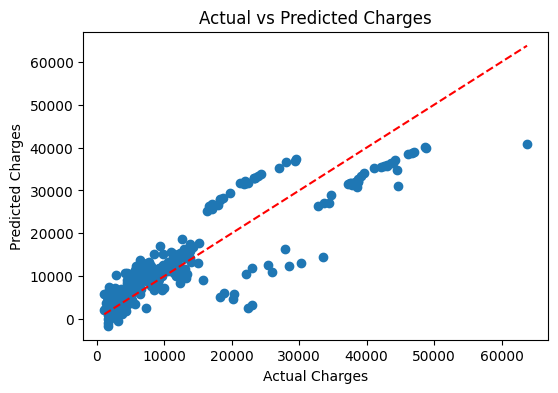


Conclusion:
- Linear Regression predicts insurance charges based on personal data.
- BMI, age, and smoking status strongly influence insurance charges.
- MAE and RMSE provide measures of model accuracy, helping evaluate prediction performance.



In [2]:
# ===============================
# Task 4: Predicting Insurance Claim Amounts
# ===============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("/kaggle/input/datasets/raimamunir/medical-cost-personal-dataset/insurance.csv")
df.head()

# ===============================
# 3. Dataset Overview
# ===============================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary statistics:\n", df.describe())

# ===============================
# 4. Data Preprocessing
# ===============================

# Encode categorical features
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])       # male=1, female=0
df['smoker'] = le.fit_transform(df['smoker']) # yes=1, no=0

# One-Hot Encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# ===============================
# 5. Exploratory Data Analysis (EDA)
# ===============================

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# BMI vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker')
plt.title("BMI vs Charges (smoker highlighted)")
plt.show()

# Age vs Charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker')
plt.title("Age vs Charges (smoker highlighted)")
plt.show()

# ===============================
# 6. Model Training
# ===============================
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ===============================
# 7. Model Evaluation
# ===============================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs predicted charges
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.show()

# ===============================
# 8. Conclusion
# ===============================
print("""
Conclusion:
- Linear Regression predicts insurance charges based on personal data.
- BMI, age, and smoking status strongly influence insurance charges.
- MAE and RMSE provide measures of model accuracy, helping evaluate prediction performance.
""")